<a href="https://colab.research.google.com/github/vikramvundyala/python_AI-ML/blob/main/U3_MH2_Plant_Images_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

Denoise the leaf images using deep learning techniques

## Learning Objectives

At the end of the Mini Hackathon, you will be able to :
* Denoise healthy/diseased leaf images using Autoencoder
* Visualize the denoised images

In [ ]:
#@title Mini Hackathon Walkthrough Video
from IPython.display import HTML

HTML("""<video width="500" height="300" controls>
  <source src="https://cdn.talentsprint.com/talentsprint1/archives/sc/misc/M3_Mini_Hackathon1_Plant_Images_Denoising.mp4" type="video/mp4">
</video>
""")

## Background

Crop losses due to diseases are a major threat to food security every year, across countries.  Conventionally, plant diseases were detected through a visual examination of the affected plants by plant pathology experts. This was often possible only after major damage had already occurred, so treatments were of limited or no use. Recently, access to smartphone based image capturing has highly increased amongst farmers and agriculturists. This has led to the successful adoption of plant disease diagnostic applications based on deep learning techniques. This is of immense value in the field of agriculture and an excellent tool for faster identification and treatment of crop diseases. It holds key importance in preventing crop based food and economic losses.
## Dataset and Methodology

The dataset for this Mini-Hackathon is derived from the 'Plant Village' Dataset.Around 4500 images of healthy and diseased leaves and their labels have been taken from the 'Plant Village' Dataset. The 4500 images consist of 5 different classes - Bell Pepper Healthy, Bell Pepper Bacterial Spot, Potato Healthy, Potato Early Blight and Potato Late Blight. The original pictures have been clicked in a well controlled environment with very less noise in the images. This is not how real world data may look like.  So we have added noise to the original images to form a noisy dataset. We can use deep learning techniques such as an autoencoder for obtaining denoised images.


## References:

[Plant Village Dataset Description](https://drive.google.com/file/d/1xGhK-KhhE8W_lfr3l6KT_9K8prHDRb9_/view?usp=sharing)


[Deep Learning for Plant Disease Detection](https://drive.google.com/file/d/1V7NgFs-YGG3G-pz3OJf2X-KQxOGRZzRu/view?usp=sharing)

[Autoencoder motivational Expt](https://colab.research.google.com/drive/1gkxGlPQ5F3PtugI_zKMeFl3fYVOmscxk?authuser=1#scrollTo=Yv3ZC8aOKJqL)


## Grading = 10 Marks

## Setup Steps

In [1]:
#@title Run this cell to download the dataset

from IPython import get_ipython
ipython = get_ipython()

notebook="M3_Mini_Hackathon1_Plant_Images_Denoising" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
   ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/PlantVillage_Noisy_Dataset.zip")
   ipython.magic("sx unzip -qq PlantVillage_Noisy_Dataset.zip")
   print ("Setup completed successfully")
   return

setup()

Setup completed successfully


**Import Libraries**

In [17]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.autograd import Variable
from torch.utils.data import DataLoader


## **Stage 1:** Data Preparation

### 1 Marks - > Prepare the dataset

1. Define transformations:
   * Transform image size to 128 by using Resize()
   * Transform the image into a number using tensor
2. Load the dataset with the defined transformations.

In [7]:
# YOUR CODE HERE for the transforming the dataset
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # Resize image to 128x128
    transforms.ToTensor()            # Convert image to tensor [0,1]
])

In [15]:
# YOUR CODE HERE for preparing trainloader and testloader set

train_dataset = datasets.ImageFolder(
    root="/content/PlantVillage/Noisy_Dataset/Train_Data",   # path to your root folder
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="/content/PlantVillage/Noisy_Dataset/Test_Data",   # path to your root folder
    transform=transform
)



In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train classes:", train_dataset.classes)
print("Test classes:", test_dataset.classes)

Train classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Test classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


## **Stage 2:** Build and Train the Model



### 2 Marks -> Write the encoder and decoder layers in one class

* Define the Autoencoder neural network
    *  First define the layers required in the  __init__ function.
    *  Build the neural network in the forward() function.

[Hint for saving the images](https://debuggercafe.com/implementing-deep-autoencoder-in-pytorch/)

In [27]:

# YOUR CODE HERE for constructing an autoencoder model

# class Autoencoder(nn.Module):
#     def __init__(self):
#         super(Autoencoder, self).__init__()

#         # ---- Encoder ----
#         self.encoder = nn.Sequential(
#             nn.Linear(128*128*3, 1024),   # input: flattened image
#             nn.ReLU(True),
#             nn.Linear(1024, 256),
#             nn.ReLU(True),
#             nn.Linear(256, 64)            # latent space (compressed)
#         )

#         # ---- Decoder ----
#         self.decoder = nn.Sequential(
#             nn.Linear(64, 256),
#             nn.ReLU(True),
#             nn.Linear(256, 1024),
#             nn.ReLU(True),
#             nn.Linear(1024, 128*128*3),
#             nn.Sigmoid()  # output values in [0,1]
#         )

#     def forward(self, x):
#         # Flatten image into vector
#         x = x.view(x.size(0), -1)

#         # Encode
#         latent = self.encoder(x)

#         # Decode
#         out = self.decoder(latent)

#         # Reshape back into image [batch, channels, height, width]
#         out = out.view(x.size(0), 3, 128, 128)
#         return out


import torch
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()

        # ---- Encoder ----
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # [3,128,128] -> [16,64,64]
            nn.ReLU(True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # [16,64,64] -> [32,32,32]
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # [32,32,32] -> [64,16,16]
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# [64,16,16] -> [128,8,8]
            nn.ReLU(True)
        )

        # ---- Decoder ---- (mirror using ConvTranspose2d)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # [128,8,8] -> [64,16,16]
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # [64,16,16] -> [32,32,32]
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # [32,32,32] -> [16,64,64]
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),   # [16,64,64] -> [3,128,128]
            nn.Sigmoid()  # pixel values in [0,1]
        )

    def forward(self, x):
        latent = self.encoder(x)   # compressed feature maps
        out = self.decoder(latent) # reconstructed image
        return out

### 2 Marks -> Train the Model and calculate the loss for dataset for each epoch.

1. Declare the loss function and optimizer
2. Create a directory for saving the output images.
2. Train the model
   *  Extract the image features only as we do not take the labels to train the autoencoder network.
   * Calculate the loss.
   * Append the loss values after every epoch and print them.
   * Save the output (denoised) images in a directory.

In [28]:
# YOUR CODE HERE for declaring the loss function and optimizer
model = ConvAutoencoder()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [29]:
# YOUR CODE HERE for defining a function for creating the directory
import os

output_dir = "autoencoder_outputs"
os.makedirs(output_dir, exist_ok=True)

In [30]:
# YOUR CODE HERE.

# Train the model and print the loss at each epoch. Also save the output (denoised) images in a directory.
from torchvision.utils import save_image

num_epochs = 20
loss_values = []

for epoch in range(num_epochs):
    epoch_loss = 0
    model.train()

    for images, _ in train_loader:   # labels (_) are ignored
        images = images.to(torch.float32)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_values.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    if (epoch+1) % 5 == 0:   # every 5 epochs
        save_image(outputs[:8], os.path.join(output_dir, f"reconstructed_epoch{epoch+1}.png"))
        save_image(images[:8], os.path.join(output_dir, f"original_epoch{epoch+1}.png"))


Epoch [1/10], Loss: 0.0211
Epoch [2/10], Loss: 0.0118
Epoch [3/10], Loss: 0.0106
Epoch [4/10], Loss: 0.0100
Epoch [5/10], Loss: 0.0096
Epoch [6/10], Loss: 0.0091
Epoch [7/10], Loss: 0.0087
Epoch [8/10], Loss: 0.0083
Epoch [9/10], Loss: 0.0081
Epoch [10/10], Loss: 0.0079


In [31]:
# YOUR CODE HERE

# Record loss of the train denoised images

with open(os.path.join(output_dir, "loss_values.txt"), "w") as f:
    for i, l in enumerate(loss_values, 1):
        f.write(f"Epoch {i}: {l}\n")

## **Stage 3:** Visualize the Denoised images

### 2 Marks -> Verify the denoised images and compare with original noisy images
1. Plot the original noisy images.
2. Plot denoised images which are saved in the directory.
3. Verify whether denoised images have less noise compared to original noisy images

**Hint:** If the noise is not reduced in the denoised images then revise the autoencoder architecture.

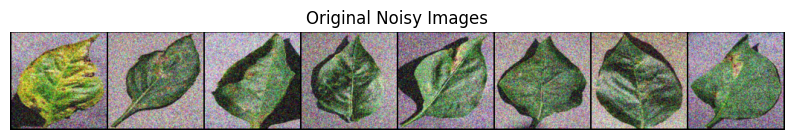

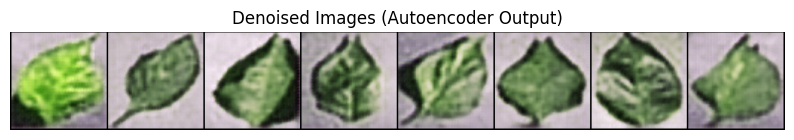

In [32]:
# YOUR CODE HERE for plotting and verifying the images (original noisy images and denoising images)
from torchvision.utils import make_grid


images, _ = next(iter(test_loader))
images = images.to(torch.float32)

plt.figure(figsize=(10,4))
grid = make_grid(images[:8], nrow=8, normalize=True)
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.title("Original Noisy Images")
plt.axis("off")
plt.show()

model.eval()
with torch.no_grad():
    denoised = model(images)

plt.figure(figsize=(10,4))
grid = make_grid(denoised[:8], nrow=8, normalize=True)
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.title("Denoised Images (Autoencoder Output)")
plt.axis("off")
plt.show()

## **Stage 4:** Test the Model

### 2 Marks -> Evaluate model with the given test data

1. Extract only the images of test loader data as we do not use the labels for the autoencoder network
2. Pass the test images through the autoencoder model to get the denoised images of the test data.
3. Calculate the loss of the test images

In [33]:
# YOUR CODE HERE for recording the loss of the test dataset

model.eval()
test_loss = 0
criterion = nn.MSELoss()

with torch.no_grad():  # no gradients needed
    for images, _ in test_loader:    # labels ignored
        images = images.to(torch.float32)

        # Forward pass
        outputs = model(images)

        # Compute reconstruction loss
        loss = criterion(outputs, images)
        test_loss += loss.item()

# Average loss over all test batches
avg_test_loss = test_loss / len(test_loader)
print(f"Test Loss (Reconstruction Error): {avg_test_loss:.4f}")

Test Loss (Reconstruction Error): 0.0078


### 1 Marks -> Visualizing and verifying test images with the original test noisy dataset

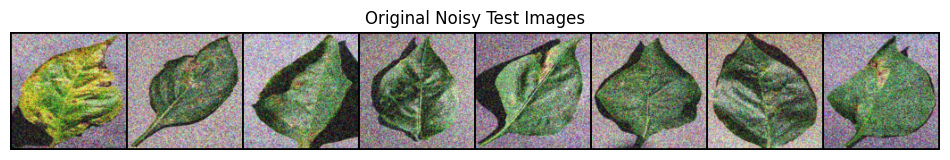

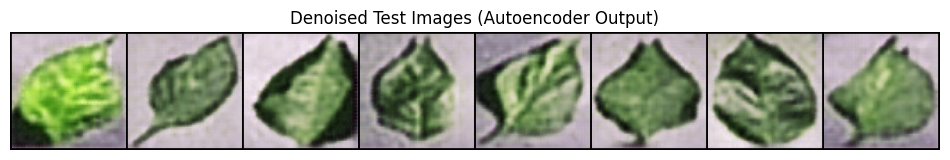

Reconstruction Loss for this batch: 0.0081


In [34]:
# YOUR CODE HERE for verification and visualization of the test denoised images and original test noisy images

import matplotlib.pyplot as plt

# Set model to evaluation
model.eval()

# Get one batch from test loader
noisy_imgs, _ = next(iter(test_loader))
noisy_imgs = noisy_imgs.to(torch.float32)

# Forward pass (denoising)
with torch.no_grad():
    denoised_imgs = model(noisy_imgs)

# ---- Plot Original Noisy Images ----
plt.figure(figsize=(12,4))
grid_noisy = make_grid(noisy_imgs[:8], nrow=8, normalize=True)
plt.imshow(grid_noisy.permute(1, 2, 0).cpu().numpy())
plt.title("Original Noisy Test Images")
plt.axis("off")
plt.show()

# ---- Plot Denoised Images ----
plt.figure(figsize=(12,4))
grid_denoised = make_grid(denoised_imgs[:8], nrow=8, normalize=True)
plt.imshow(grid_denoised.permute(1, 2, 0).cpu().numpy())
plt.title("Denoised Test Images (Autoencoder Output)")
plt.axis("off")
plt.show()

# ---- Calculate Test Loss ----
criterion = nn.MSELoss()
test_loss = criterion(denoised_imgs, noisy_imgs).item()
print(f"Reconstruction Loss for this batch: {test_loss:.4f}")